# Jupyter notebook

Co to jest?
1. Potężny (Read-Eval-Print Loop) połączony z notatnikiem. Kod jest wykonywany komórka po komórce, a środowisko trzyma stan w pamięci RAM pomiędzy tymi wykonaniami
2. Jupyter to narzędzie do szybkiego eksperymentowania i sprawdzania hipotez. To taki inżynierski brudnopis. W prawdziwym świecie, gdy udowodnimy w Jupyterze, że model działa i ma wartość biznesową, bierzemy ten kod, refaktoryzujemy go, ubieramy w klasy i wrzucamy do normalnych pipeline'ów (np. Airflow czy MLflow), które odpalają się cyklicznie. Dzisiaj jesteśmy w laboratorium.


Jupyter ma dwa tryby pracy (jak edytor Vim):

1. Tryb Edycji (zielona ramka / migający kursor) – piszesz kod wewnątrz komórki.

2. Tryb nawigacji (niebieska ramka) – nawigujesz po całym notatniku i zarządzasz komórkami.

### Ścigawka
Przechodzenie między trybami
- Enter – wejdź do komórki (Tryb Edycji).
- Esc – wyjdź z komórki (Tryb nawigacji).

Typy komórek:
- M (Markdown) – zamień komórkę z kodem na tekstową (do notatek).
- Y – zamień komórkę tekstową z powrotem na kod Pythona.

Uruchamianie kodu (Działa w obu trybach)
- Shift + Enter – uruchamia obecną komórkę i od razu przechodzi do następnej (najczęściej używany skrót, pozwala szybko "przeklikać" notatnik z góry na dół).
- Ctrl + Enter (lub Cmd + Enter na Macu) – uruchamia komórkę, ale zostaje na niej (przydatne, gdy testujesz jedną funkcję i ciągle ją zmieniasz).

Zarządzanie komórkami (Tylko w Trybie Komend - wciśnij najpierw Esc)
- A (Above) – dodaj nową, pustą komórkę powyżej.
- B (Below) – dodaj nową, pustą komórkę poniżej.
- D , D (podwójne naciśnięcie D) – usuń zaznaczoną komórkę.
- Z – cofnij usunięcie komórki


Podpowiedzi w kodzie (Tylko w Trybie Edycji)
- Tab – autouzupełnianie zmiennych i metod (jak w IDE).
- Shift + Tab – otwiera dymek z dokumentacją (docstringiem) dla danej funkcji

# Pandas - Inżynieria danych w pigułce

Pandas to biblioteka do manipulacji danymi tabularycznymi. Dla programisty to po prostu SQL wewnątrz Pythona (i to na sterydach).

In [2]:
import pandas as pd
import numpy as np
import os

DATA_PATH = '../../data/input/'
df_orders = pd.read_csv(os.path.join(DATA_PATH, 'olist_orders_dataset.csv'))
df_customers = pd.read_csv(os.path.join(DATA_PATH, 'olist_customers_dataset.csv'))

# Wyświetlanie pierwszych 5 wierszy
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### 1. Filtrowanie i Inspekcja
W Pandas używamy masek bitowych lub metody `.query()`.

In [3]:
# Sprawdź statystyki i brakujące dane
print(df_orders.info())

# Filtrowanie: tylko zamówienia dostarczone (delivered)
df_delivered = df_orders.query("order_status == 'delivered'")

df_delivered.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
None


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


### 2. Łączenie danych (SQL-style JOIN)
Większość problemów wymaga danych z wielu tabel. Połączymy zamówienia z klientami, aby dowiedzieć się, skąd pochodzą nasi kupujący.

In [5]:
# LEFT JOIN po kluczu customer_id
df_merged = pd.merge(df_orders, df_customers, on='customer_id', how='left')

df_merged.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [6]:

# Sprawdźmy ile zamówień mamy z poszczególnych stanów (top 5)
state_rank = df_merged['customer_state'].value_counts().head(5)
print("Top 5 stanów pod względem zamówień:")
print(state_rank)

Top 5 stanów pod względem zamówień:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64


### 3. Pivot Tables (Tabele Przestawne)
Pozwalają na szybkie przekształcenie danych long -> wide. Zobaczmy rozkład statusów zamówień w 10 najpopularniejszych stanach.

In [7]:
# Filtrujemy tylko top 10 stanów dla czytelności
top_states = df_merged['customer_state'].value_counts().nlargest(10).index
df_subset = df_merged[df_merged['customer_state'].isin(top_states)]

# Tworzymy pivot table: Indeks to stany, kolumny to statusy, wartości to licznik zamówień
df_pivot = df_subset.pivot_table(index='customer_state', columns='order_status', values='order_id', aggfunc='count', fill_value=0)

df_pivot

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
customer_state,,,,,,,,
BA,0,16,0,3256,9,11,68,20
DF,0,7,1,2080,3,7,30,12
ES,0,9,0,1995,4,2,17,6
GO,0,13,0,1957,5,5,31,9
MG,1,64,0,11354,39,31,71,75
PR,0,22,1,4923,15,15,29,40
RJ,0,86,1,12350,26,32,289,68
RS,0,25,1,5345,20,14,37,24
SC,0,19,0,3546,12,14,28,18


# Plotly - Interaktywne Wizualizacje

Dlaczego Plotly? Ponieważ generuje wykresy w HTML/JS, które można przeglądać interaktywnie w przeglądarce (zoom, hover, selekcja).
Tutoriale będą pokazywały - Matplotlib - legacy

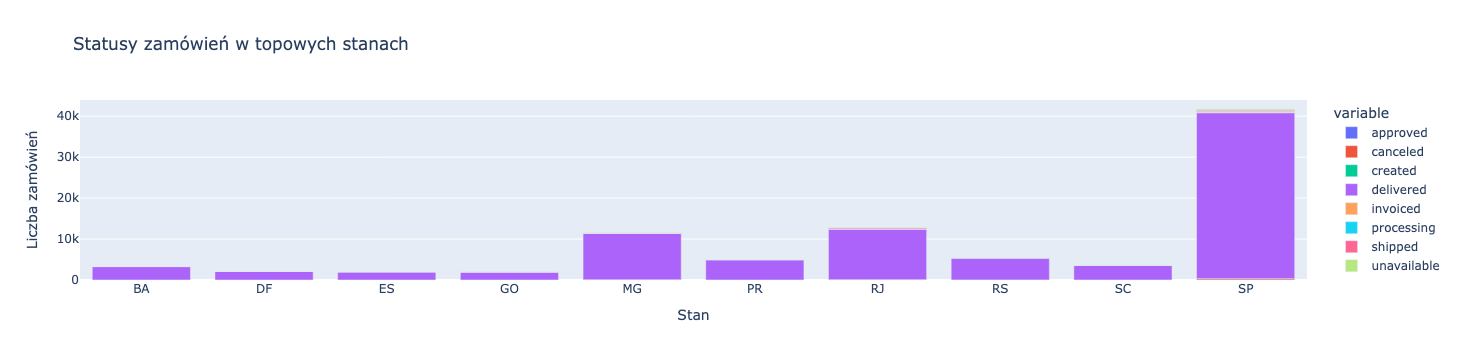

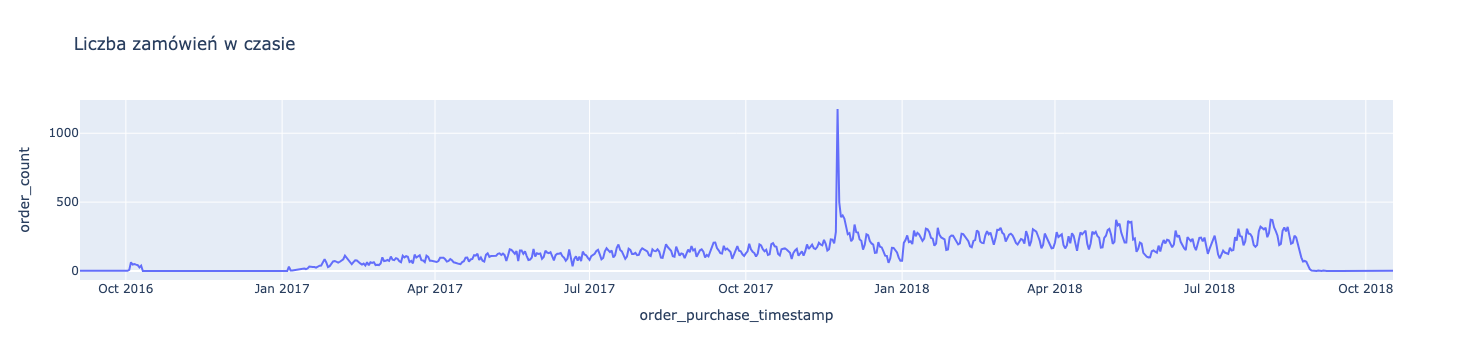

In [8]:
import plotly.express as px

# Wizualizacja naszej tabeli przestawnej (Stacked Bar Chart)
fig_pivot = px.bar(df_pivot.reset_index(), x='customer_state', y=df_pivot.columns, 
                   title='Statusy zamówień w topowych stanach',
                   labels={'value': 'Liczba zamówień', 'customer_state': 'Stan'})
fig_pivot.show()

# Dodatkowo: Interaktywny szereg czasowy
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_daily = df_orders.set_index('order_purchase_timestamp').resample('D').size().reset_index(name='order_count')

fig_line = px.line(df_daily, x='order_purchase_timestamp', y='order_count', 
                   title='Liczba zamówień w czasie')
fig_line.show()

# Zadanie